---
tags: [tutorial]
---

# Controlling Gates and Sub-Kernels with `qmc.control`

[Tutorial 03](03_vector_slicing.ipynb) showed how `VectorView`
slices let one helper kernel operate on a contiguous chunk of a
larger register. This chapter is about a related but distinct
building block: turning *any* gate (built-in or a custom
`@qmc.qkernel`) into a *controlled* version of itself with
`qmc.control`.

`qmc.control(fn)` returns a `ControlledGate` wrapper that, when
called, emits the controlled-U form of `fn`. The wrapper supports:

- **Concrete control counts** (`num_controls: int`) — the most
  common case, where you know at decoration time how many control
  qubits there are.
- **Symbolic control counts** (`num_controls: UInt`) — the number
  of controls is determined at compile time from `bindings`.
- **Index selection** (`controlled_indices=`) — in symbolic mode,
  pick a *subset* of a control pool to actually use as controls;
  the rest pass through untouched.
- **Powers** (`power=`) — control `U^k` instead of `U`, which is
  the standard pattern for QPE / amplitude estimation.

This chapter walks through each form with a small executable
example, then catalogues the patterns that the API rejects (with
the exception type each one raises, so the examples double as
regression tests).

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.transpiler.errors import QubitConsumedError
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## 1. The minimal example: controlled-RX

The smallest interesting use of `qmc.control` is wrapping a single
built-in rotation. `qmc.rx(q, angle)` is a one-qubit gate; passing
it to `qmc.control` produces a two-qubit controlled-RX.

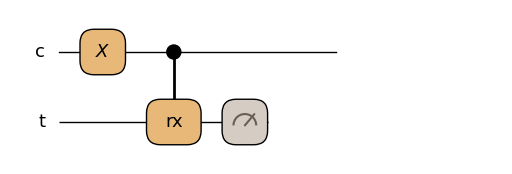

In [3]:
@qmc.qkernel
def crx_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # Drive the control to |1> so the controlled rotation fires.
    c = qmc.x(c)
    crx = qmc.control(qmc.rx)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_demo.draw()

A few observations on the call site:

- `qmc.control(qmc.rx)` is evaluated at *decoration time*. The
  returned `ControlledGate` (here bound to `crx`) is reusable.
- When you call `crx(c, t, angle=...)`, the control qubits come
  first as positional arguments, then the targets, then any
  classical keyword arguments — the same order as the underlying
  `qmc.rx(q, angle)` signature, with one extra control prefix.
- The keyword name for the classical parameter is whatever the
  wrapped function uses (`angle` for `qmc.rx`, `theta` for
  `qmc.p`, etc.).

## 2. Two modes at a glance

Almost every shape `qmc.control` accepts falls into one of two
modes, decided by what you pass for `num_controls`:

| Mode | `num_controls` | Control argument(s) | Index selector |
| --- | --- | --- | --- |
| **Concrete** | `int` (default `1`) | one or more `Qubit` / `VectorView` / `Vector[Qubit]` positional args whose qubit counts sum to `num_controls` | not allowed |
| **Symbolic** | a `qmc.UInt` handle | a single `Vector[Qubit]` *pool* (the actual controls are selected from it at compile time) | `controlled_indices=` chooses which slots of the pool are active |

Sections 3 and 4 expand each mode with small, runnable examples.
Section 5 collects the patterns the API rejects, paired with the
exact exception you will see.

## 3. Concrete mode

In concrete mode the number of control qubits is fixed at
decoration time. The wrapper checks that the qubits you pass
positionally add up to exactly that number, then emits a
controlled-U where the inner block is the wrapped function.

### 3.1 Wrapping a built-in gate

Built-in gate functions (`qmc.rx`, `qmc.h`, `qmc.p`, ...) can go
straight into `qmc.control` — no wrapper kernel needed. The
minimal CRX in Section 1 is the canonical example; here is the
even smaller case of controlling `qmc.h`:

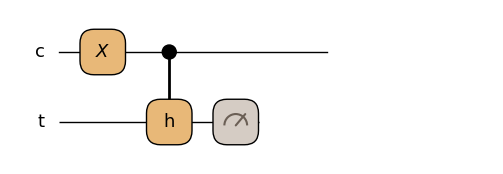

In [4]:
@qmc.qkernel
def ch_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    ch = qmc.control(qmc.h)
    c, t = ch(c, t)
    return qmc.measure(t)


ch_demo.draw()

### 3.2 Multiple controls (`num_controls > 1`)

Setting `num_controls=2` and wrapping `qmc.x` gives a Toffoli
(CCX). The two control qubits are positional arguments in front
of the target.

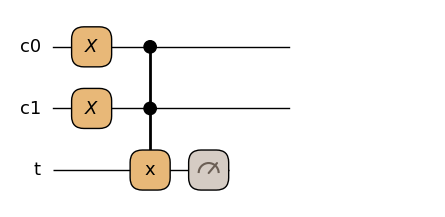

In [5]:
@qmc.qkernel
def toffoli_demo() -> qmc.Bit:
    c0 = qmc.qubit(name="c0")
    c1 = qmc.qubit(name="c1")
    t = qmc.qubit(name="t")
    c0 = qmc.x(c0)
    c1 = qmc.x(c1)
    ccx = qmc.control(qmc.x, num_controls=2)
    c0, c1, t = ccx(c0, c1, t)
    return qmc.measure(t)


toffoli_demo.draw()

### 3.3 Wrapping a user `@qmc.qkernel`

When the body you want to control is more than a single
primitive, write it as a `@qmc.qkernel` and pass *that* to
`qmc.control`. The wrapped kernel can have arbitrarily many
gates; the controlled-U pass sees the whole block.

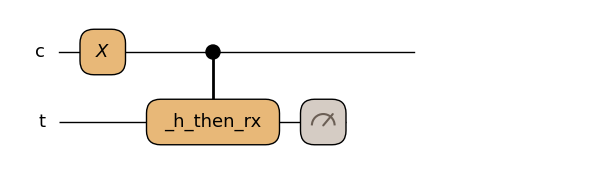

In [6]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


@qmc.qkernel
def controlled_h_rx_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_h_then_rx)
    c, t = cg(c, t, theta=math.pi / 4)
    return qmc.measure(t)


controlled_h_rx_demo.draw()

### 3.4 Mixing scalar Qubit and `VectorView` controls

The positional control prefix can mix scalar `Qubit` handles and
`VectorView` slices freely, as long as the total qubit count adds
up to `num_controls`. Here `qs[0]` (1 qubit) plus `qs[1:3]`
(2 qubits) supplies the three controls for a `num_controls=3`
wrapped Hadamard.

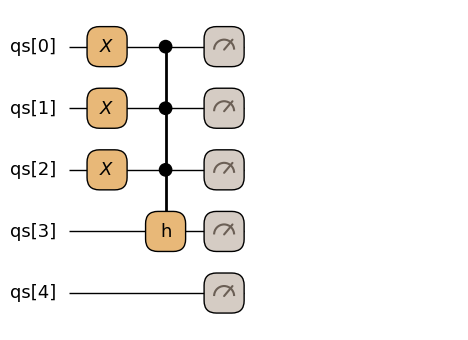

In [7]:
@qmc.qkernel
def mixed_controls_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(5, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    cg = qmc.control(qmc.h, num_controls=3)
    qs[0], qs[1:3], qs[3] = cg(qs[0], qs[1:3], qs[3])
    return qmc.measure(qs)


mixed_controls_demo.draw()

### 3.5 Sub-kernels taking `Vector[Qubit]`

A wrapped kernel can take a `Vector[Qubit]` argument. The caller
then passes a `Vector` or `VectorView` of the matching length,
and the controlled-U emit pass expands the body per-element.

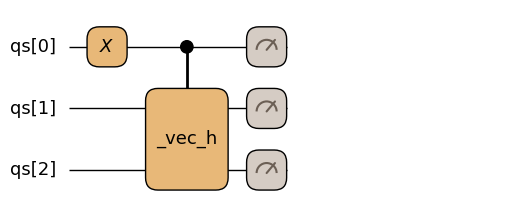

In [8]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


@qmc.qkernel
def controlled_vec_h_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    cg = qmc.control(_vec_h, num_controls=1)
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


controlled_vec_h_demo.draw()

### 3.6 Default values from `@qmc.qkernel` signatures

If the wrapped `@qmc.qkernel` declares a Python default for a
classical parameter, callers may omit that keyword. The wrapper
fills it in via `inspect.Signature.bind` + `apply_defaults`, so
the default value reaches the controlled-U just like a normal
direct call.

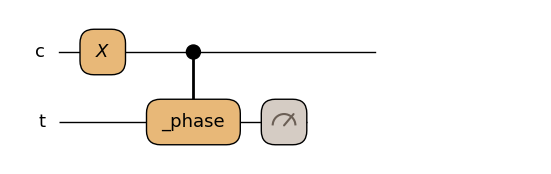

In [9]:
@qmc.qkernel
def _phase(q: qmc.Qubit, theta: qmc.Float = math.pi / 2) -> qmc.Qubit:
    return qmc.rx(q, theta)


@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_phase)
    c, t = cg(c, t)  # theta defaults to math.pi / 2
    return qmc.measure(t)


default_arg_demo.draw()

### 3.7 Classical keyword arguments in any order

Classical kwargs at the call site are matched by name and
re-ordered to follow the wrapped kernel's signature internally,
so both `cg(c, t, alpha=..., beta=...)` and
`cg(c, t, beta=..., alpha=...)` produce identical circuits.

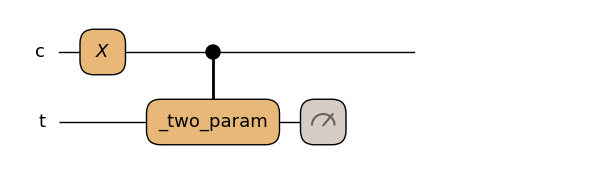

In [10]:
@qmc.qkernel
def _two_param(q: qmc.Qubit, alpha: qmc.Float, beta: qmc.Float) -> qmc.Qubit:
    q = qmc.rx(q, alpha)
    q = qmc.rz(q, beta)
    return q


@qmc.qkernel
def kwargs_in_order() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, alpha=0.7, beta=1.3)
    return qmc.measure(t)


@qmc.qkernel
def kwargs_reversed() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, beta=1.3, alpha=0.7)
    return qmc.measure(t)


# Both call sites compile to the same circuit.
exe_a = transpiler.transpile(kwargs_in_order)
exe_b = transpiler.transpile(kwargs_reversed)
assert str(exe_a.compiled_quantum[0].circuit) == str(exe_b.compiled_quantum[0].circuit)

kwargs_in_order.draw()

### 3.8 Controlling `U^k` with `power=`

Passing `power=k` controls the *k-th power* of the wrapped
unitary instead of `U` itself. This is the standard pattern in
QPE: the j-th register applies a controlled-`U^(2**j)`.
`power` accepts a Python `int` (resolved at compile time) or a
`qmc.UInt` handle (resolved at transpile time from `bindings`).

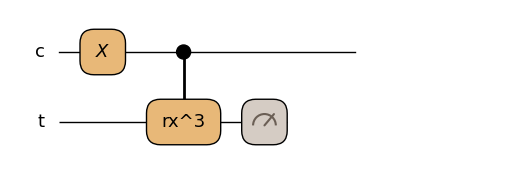

In [11]:
@qmc.qkernel
def power_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)
    c, t = cg(c, t, angle=math.pi / 4, power=3)
    return qmc.measure(t)


power_demo.draw()

## 4. Symbolic mode

Concrete mode is enough when you can write the number of
controls as a Python literal. When the count comes from a kernel
argument — for example, "make this an $n-1$ way multi-controlled
X over a register of size $n$" — you want *symbolic* mode.

In symbolic mode you set `num_controls` to a `qmc.UInt` handle
(typically a kernel parameter or an arithmetic expression
involving one). The call site then passes the *whole* control
pool as a single argument; the compile pass figures out how many
active controls that pool yields once `bindings` resolves the
count.

### 4.1 `num_controls = n` over a whole pool

The simplest symbolic shape: the entire pool becomes the controls.

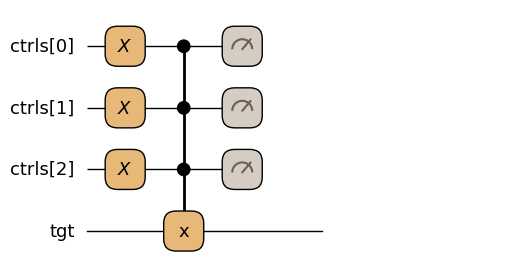

In [12]:
@qmc.qkernel
def symbolic_pool(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    ctrls = qmc.qubit_array(n, "ctrls")
    tgt = qmc.qubit(name="tgt")
    ctrls[0] = qmc.x(ctrls[0])
    ctrls[1] = qmc.x(ctrls[1])
    ctrls[2] = qmc.x(ctrls[2])
    cg = qmc.control(qmc.x, num_controls=n)
    ctrls, tgt = cg(ctrls, tgt)
    return qmc.measure(ctrls)


symbolic_pool.draw(n=3)

### 4.2 Canonical `n-1` multi-controlled form

A common pattern is to use the first `n-1` qubits of a register
as controls and the last one as the target. The bound on
`num_controls` is the symbolic expression `n - 1`, and the slice
`qs[0:n-1]` provides the control pool.

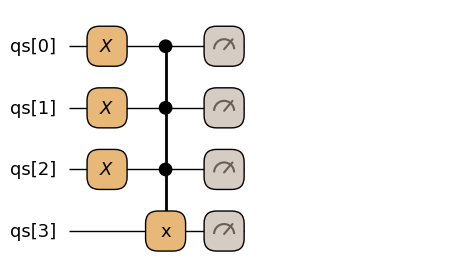

In [13]:
@qmc.qkernel
def mcx_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(n, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    mcx = qmc.control(qmc.x, num_controls=n - 1)
    qs[0 : n - 1], qs[n - 1] = mcx(qs[0 : n - 1], qs[n - 1])
    return qmc.measure(qs)


mcx_demo.draw(n=4)

### 4.3 Selecting a subset with `controlled_indices=`

Sometimes the control pool is wider than the number of active
controls you want. `controlled_indices=` (symbolic mode only)
selects exactly which slots of the pool participate; the rest
pass through untouched.

Here the pool has 4 qubits but only the first three are wired in
as active controls. The fourth slot is along for the ride and
emits no extra gate of its own.

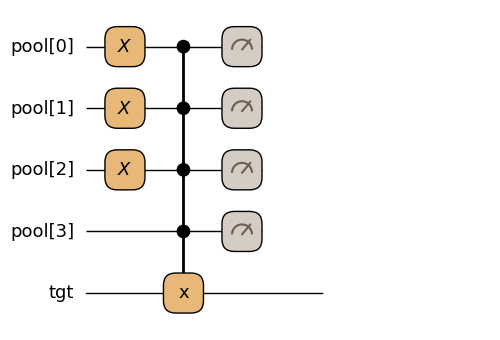

In [14]:
@qmc.qkernel
def subset_pool(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[2] = qmc.x(pool[2])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, controlled_indices=[0, 1, 2])
    return qmc.measure(pool)


subset_pool.draw(n=4, k_ctrls=3)

### 4.4 `controlled_indices` with `UInt` entries

Entries inside `controlled_indices` may be Python `int` literals,
`qmc.UInt` handles, or arithmetic expressions over `UInt` values
(such as `k - 1`). Literal-`int` entries are validated at
decoration / compose time; symbolic entries are validated at
transpile time once `bindings` makes them concrete.

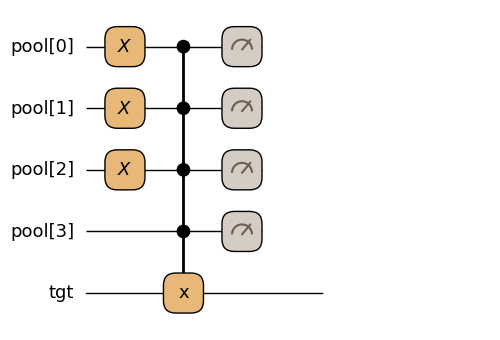

In [15]:
@qmc.qkernel
def subset_pool_with_uint(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[2] = qmc.x(pool[2])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, controlled_indices=[0, 1, k_ctrls - 1])
    return qmc.measure(pool)


subset_pool_with_uint.draw(n=4, k_ctrls=3)

## 5. Patterns that don't work

The next group of cells lists the call shapes `qmc.control`
rejects and the exception each one raises. They are structured
so the tutorial doubles as a regression check: a helper runs
each case under `try / except`, asserts that the *expected*
exception type came out, and prints the message. If a future
code change accidentally changed which exception fires (or
stopped raising entirely), the docs build would fail.

In [16]:
def expect_error(label: str, exc_type: type, body) -> None:
    """Assert that *body* raises *exc_type*; print the message.

    Used as a structured try/except across the don't-work cases.
    Re-raises an ``AssertionError`` if either the wrong exception
    type comes out or no exception comes out at all, so the
    notebook itself acts as a regression test.
    """
    try:
        body()
    except exc_type as exc:
        print(f"[{type(exc).__name__}] {label}: {exc}")
        return
    except Exception as exc:
        raise AssertionError(
            f"{label}: expected {exc_type.__name__}, got {type(exc).__name__}: {exc}"
        ) from exc
    raise AssertionError(
        f"{label}: expected {exc_type.__name__}, but no exception was raised"
    )

### 5.1 Control qubit count does not match `num_controls`

Concrete mode counts positional control qubits. Passing a slice
that is too wide (or too narrow) for the declared `num_controls`
is rejected at compose time as a `ValueError`.

In [17]:
def case_count_mismatch() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        qs = qmc.qubit_array(6, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, t = cg(qs[0:5], qs[5])  # 5 qubits supplied, 3 expected
        qs[0:5] = view
        return qmc.measure(qs[5])

    _ = kernel.block


expect_error("control count mismatch", ValueError, case_count_mismatch)

[ValueError] control count mismatch: concrete num_controls=3: positional argument #0 would push the control qubit count from 0 to 5, crossing the control / sub-kernel boundary mid-argument.  Split the argument so the boundary falls between args.


### 5.2 `controlled_indices=` in concrete mode

`controlled_indices` only makes sense when there is a control
*pool* to select from, which is a symbolic-mode concept.
Supplying it alongside a concrete `num_controls` raises
`ValueError` at compose time.

In [18]:
def case_controlled_indices_in_concrete() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)  # num_controls defaults to 1 (concrete)
        c, t = cg(c, t, controlled_indices=[0])
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "controlled_indices in concrete mode",
    ValueError,
    case_controlled_indices_in_concrete,
)

[ValueError] controlled_indices in concrete mode: controlled_indices is only valid in symbolic mode (num_controls=UInt).  Got concrete num_controls; concrete-mode controls are positional and have no selection step (see design §1.1).


### 5.3 Using the same qubit twice

Each `Qubit` handle can be consumed once. Passing the same
scalar `Qubit` to both a control and the target (or to two
control positions) is caught by the linear-type machinery as a
`QubitConsumedError`. Slice overlaps go through a related
borrow-tracker error path.

In [19]:
def case_alias() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        q = qmc.qubit(name="q")
        cg = qmc.control(qmc.x)
        a, b = cg(q, q)  # control and target both reference q
        return qmc.measure(b)

    _ = kernel.block


expect_error("alias (q used twice)", QubitConsumedError, case_alias)

[QubitConsumedError] alias (q used twice): Qubit 'qubit_06003a08' was already consumed by 'ControlledU[control]' and cannot be used again in 'ControlledU[target]'.

Affine type rule: Each qubit handle can only be used once. After a gate operation, reassign the result to use the new handle.

Fix:
  q = qm.h(q)  # Reassign to capture the new handle
  q = qm.x(q)  # Use the reassigned handle


### 5.4 Symbolic-length `VectorView` in concrete mode

Concrete mode needs to compute the qubit count of every control
argument at compile time. A slice whose length depends on a
`UInt` (here `qs[0:m]` for a symbolic `m`) is not yet supported
in concrete mode and raises `NotImplementedError`. The
workaround is to switch to symbolic mode — `num_controls=m`
accepts exactly this shape (see Section 4.1).

In [20]:
def case_symbolic_view_in_concrete() -> None:
    @qmc.qkernel
    def kernel(m: qmc.UInt) -> qmc.Bit:
        qs = qmc.qubit_array(m, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, q_out = cg(qs[0:m], qs[m - 1])
        qs[0:m] = view
        qs[m - 1] = q_out
        return qmc.measure(qs[m - 1])

    _ = kernel.block


expect_error(
    "symbolic-length VectorView in concrete mode",
    NotImplementedError,
    case_symbolic_view_in_concrete,
)

[NotImplementedError] symbolic-length VectorView in concrete mode: concrete num_controls with a symbolic-length Vector / VectorView control is not yet implemented in the frontend (tracked under Step 2.b of the controlled-API redesign).


### 5.5 Typo in a classical keyword argument

`qmc.control` inspects the wrapped kernel's signature, so an
unknown keyword name is caught at compose time. The error
message lists the parameters the wrapper actually understands.

In [21]:
def case_kwarg_typo() -> None:
    @qmc.qkernel
    def _gate(q: qmc.Qubit, angle: qmc.Float) -> qmc.Qubit:
        return qmc.rx(q, angle)

    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(_gate)
        c, t = cg(c, t, agnle=0.5)  # typo: agnle -> angle
        return qmc.measure(t)

    _ = kernel.block


expect_error("classical kwarg typo", TypeError, case_kwarg_typo)

[TypeError] classical kwarg typo: control(): unknown parameter(s) ['agnle']. The wrapped kernel's classical parameters are ['angle'].


### 5.6 Invalid entries in `controlled_indices`

Literal entries are validated at compose time. Three common
mistakes:

- `bool` values (`True` / `False`) are rejected even though
  Python treats them as ints, to prevent the silent
  ``True == 1`` / ``False == 0`` confusion. Use an explicit
  `int(...)` cast if you really mean that.
- Negative literals are rejected — pool indices are unsigned.
- Duplicate literals are rejected because each pool slot can
  wire in at most one active control.

In [22]:
def case_bool_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[True, 1])
        return qmc.measure(pool)

    _ = kernel.block


def case_negative_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[-1, 0, 1])
        return qmc.measure(pool)

    _ = kernel.block


def case_duplicate_entry() -> None:
    @qmc.qkernel
    def kernel(k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(3, "pool")
        tgt = qmc.qubit(name="tgt")
        cg = qmc.control(qmc.z, num_controls=k_ctrls)
        pool, tgt = cg(pool, tgt, controlled_indices=[0, 0, 1])
        return qmc.measure(pool)

    _ = kernel.block


expect_error("controlled_indices: bool entry", TypeError, case_bool_entry)
expect_error("controlled_indices: negative entry", ValueError, case_negative_entry)
expect_error("controlled_indices: duplicate entry", ValueError, case_duplicate_entry)

[TypeError] controlled_indices: bool entry: controlled_indices: bool entry (True) is not allowed; cast to int explicitly if intentional.
[ValueError] controlled_indices: negative entry: controlled_indices: negative entry (-1) is not allowed.
[ValueError] controlled_indices: duplicate entry: controlled_indices: duplicate int entry (0).


### 5.7 Invalid `power`

`power` must be a strictly positive integer (Python `int` or
`qmc.UInt`). Zero and negative values raise `ValueError`, and a
Python `bool` is rejected as `TypeError` so that `power=True`
does not silently mean `power=1`.

In [23]:
def case_power_zero() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=0)
        return qmc.measure(t)

    _ = kernel.block


def case_power_bool() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=True)
        return qmc.measure(t)

    _ = kernel.block


expect_error("power=0", ValueError, case_power_zero)
expect_error("power=True (bool)", TypeError, case_power_bool)

[ValueError] power=0: power must be a strictly positive integer, got 0.
[TypeError] power=True (bool): power must be a positive integer, got bool (True). Use an integer value like power=1 or power=2.


### 5.8 `num_controls=0`

A controlled gate with zero controls is just the underlying
gate, which makes the wrapper meaningless. `qmc.control`
rejects this at decoration time as `ValueError`.

In [24]:
def case_num_controls_zero() -> None:
    qmc.control(qmc.x, num_controls=0)


expect_error("num_controls=0", ValueError, case_num_controls_zero)

[ValueError] num_controls=0: num_controls must be >= 1, got 0.


### 5.9 Plain function with a Python default

A `qmc.control` *wrapped* callable that is not a `@qmc.qkernel`
(just a plain Python function) is auto-wrapped on the fly. The
auto-wrapper cannot synthesize Python-side default values for
classical parameters into the IR, so plain functions with
defaults are rejected at decoration time. The fix is to mark
the function as a `@qmc.qkernel` (where defaults are tracked
end-to-end) or to drop the default and pass the value
explicitly at the call site.

In [25]:
def case_plain_fn_with_default() -> None:
    def _bad_sub(q: qmc.Qubit, theta: qmc.Float = 0.5) -> qmc.Qubit:
        return qmc.rx(q, theta)

    qmc.control(_bad_sub)


expect_error("plain function with default value", TypeError, case_plain_fn_with_default)

[TypeError] plain function with default value: control(): parameter 'theta' of '_bad_sub' has a default value (0.5), which the wrapper synthesizer does not propagate. Wrap the function in @qmc.qkernel manually.


## 6. Summary

`qmc.control(fn, num_controls=...)` returns a reusable
`ControlledGate`. Two modes cover almost every case:

- **Concrete** (`num_controls: int`): write the controls
  positionally — scalar `Qubit`, `VectorView` slices, whole
  `Vector[Qubit]`, or any mixture whose qubit count adds up to
  `num_controls`. Classical kwargs follow the wrapped kernel's
  signature; `controlled_indices=` is not accepted.
- **Symbolic** (`num_controls: qmc.UInt`): pass a single pool
  as the control argument. The active subset is the whole pool
  by default, or a `controlled_indices=` subset (with `int` or
  `UInt` entries) when only some slots should fire.

Reach for symbolic mode whenever the control count is a kernel
parameter or an expression over one — including the very common
"all but one" form (`num_controls=n-1`). Reach for concrete
mode when the count is a literal and the controls live on
specific qubits you can name.

Section 5 doubles as a regression test for the validation rules
of both modes: every error case asserts the expected exception
type, so a future change that loses (or changes) a check would
fail the docs build.